# Burst Correlation Experiment

**Question:** What happens when finetune (burst) functions are correlated with pretrain functions?

**Setup:** Each slot has `n_a` pretrain functions and `n_burst_fns` burst functions. "Correlation" means some burst bijections are *copies* of pretrain bijections in the same slot (but labelled with different function tokens, e.g. F19 instead of F1). The model must still learn that F19 maps to the same permutation as F1, but the underlying computation is identical.

**Sweep:** For each correlation level × concentration (burst_frac), we measure burst learning speed, peak accuracy, and forgetting.

**Correlation levels:** With `n_burst_fns=N`, we can test correlations at steps of `1/N`. E.g. N=8 gives 0%, 12.5%, 25%, 37.5%, 50%, 62.5%, 75%, 87.5%, 100%.

In [1]:
import sys, os
os.chdir("/workspace/compositional_capabilities_burst")
sys.path.insert(0, ".")
from simple import pretrain, finetune, forget, report, interp
from simple.model import load_model
from simple.interp import compute_fisher_eigenvectors
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

OUT = "data/correlation_burst"
SEEDS = [43, 45, 46]  # multiple seeds for error bars
BATCH_SIZE = 512

# ── Experiment knobs ──────────────────────────────────────────────────
N_A = 5               # pretrain functions per slot
N_BURST_FNS = 5        # burst functions (more = finer correlation steps)
DEPTH = 3
BURST_POS = 3

# Correlation levels: fraction of burst fns that copy a pretrain fn
# With N_BURST_FNS=8, step = 1/8 = 0.125
CORRELATIONS = np.linspace(0, 1.0, 1+N_BURST_FNS)  # 0, 0.125, 0.25, ..., 1.0

# Concentration sweep (burst fraction in training mix)
FRACS = [1.0, 0.9, 0.8, 0.7, 0.6, 0.5]


In [2]:
CORRELATIONS

array([0. , 0.2, 0.4, 0.6, 0.8, 1. ])

## Data Generation with Correlation

`make_data_correlated(correlation=0.5)` generates data where 50% of burst bijections are copies of pretrain bijections from the same slot. The function tokens are still unique (F19 != F1), so the model must learn the association from examples — but the underlying permutation is identical.

In [3]:
from simple.data import make_data, _build_vocab, _gen_pool, _pad_pools, _cat


def make_data_correlated(
    *,
    correlation: float = 0.0,
    n_alph: int = 10,
    seq_len: int = 6,
    n_a: int = N_A,
    depth: int = DEPTH,
    burst_pos: int = BURST_POS,
    n_burst_fns: int = N_BURST_FNS,
    seed: int = 42,
    n_docs: int = 100,
    n_eval: int = 100,
) -> dict:
    """Like make_data, but some burst bijections copy pretrain bijections.

    Args:
        correlation: fraction of burst fns that are copies of pretrain fns
                     in the same slot. 0.0 = fully novel, 1.0 = all copied.
                     n_correlated = round(correlation * n_burst_fns).
                     Copies cycle through pretrain fns if n_correlated > n_a.
    """
    # Generate base data (all unique bijections)
    data = make_data(
        n_alph=n_alph, seq_len=seq_len, n_a=n_a, depth=depth,
        burst_pos=burst_pos, n_burst_fns=n_burst_fns, seed=seed,
        n_docs=n_docs, n_eval=n_eval,
    )

    if correlation <= 0.0:
        data["task_info"]["correlation"] = 0.0
        data["task_info"]["n_correlated"] = 0
        return data

    # Identify pretrain function indices for the burst slot
    burst_tok_pos = depth - burst_pos + 1
    pretrain_fns_in_slot = list(range((burst_tok_pos - 1) * n_a + 1,
                                       burst_tok_pos * n_a + 1))

    # How many burst bijections to replace
    n_correlated = round(correlation * n_burst_fns)
    n_correlated = min(n_correlated, n_burst_fns)

    bijections = data["bijections"]
    b_stars = data["b_stars"]

    # Replace first n_correlated burst bijections with pretrain copies (cycling)
    for i in range(n_correlated):
        src_idx = pretrain_fns_in_slot[i % len(pretrain_fns_in_slot)]
        bijections[b_stars[i]] = bijections[src_idx].copy()

    # Regenerate pools with modified bijections
    import itertools
    token_idx = data["token_idx"]
    fn_tok = data["fn_tok"]

    pos_fns = {p: list(range((p - 1) * n_a + 1, p * n_a + 1))
               for p in range(1, depth + 1)}

    other_combos = list(itertools.product(
        *[pos_fns[p] for p in range(1, depth + 1)]))
    rng = np.random.RandomState(seed)
    rng.shuffle(other_combos)
    other_tasks = [("other",) + combo for combo in other_combos]

    non_bp = [p for p in range(1, depth + 1) if p != burst_tok_pos]
    remaining = list(itertools.product(*[pos_fns[p] for p in non_bp]))
    burst_tasks = []
    for b in b_stars:
        for combo in remaining:
            fns = list(combo)
            fns.insert(burst_tok_pos - 1, b)
            burst_tasks.append(("burst",) + tuple(fns))

    np.random.seed(seed)
    bg_pool = _gen_pool(other_tasks, n_docs, bijections, seq_len, token_idx, fn_tok)
    target_pool = _gen_pool(burst_tasks, n_docs, bijections, seq_len, token_idx, fn_tok)
    eval_other_pool = _gen_pool(other_tasks[:min(8, len(other_tasks))],
                                n_eval, bijections, seq_len, token_idx, fn_tok)
    eval_burst_pool = _gen_pool(burst_tasks, n_eval, bijections, seq_len, token_idx, fn_tok)

    bg_pool, target_pool, eval_other_pool, eval_burst_pool = _pad_pools(
        bg_pool, target_pool, eval_other_pool, eval_burst_pool)

    eval_other = _cat(eval_other_pool)
    eval_burst = _cat(eval_burst_pool)

    tasks_per_fn = len(burst_tasks) // n_burst_fns
    eval_budget = tasks_per_fn * n_eval
    if eval_burst.shape[0] > eval_budget:
        idx = np.random.permutation(eval_burst.shape[0])[:eval_budget]
        eval_burst = eval_burst[idx]

    data["bg_pool"] = bg_pool
    data["target_pool"] = target_pool
    data["eval_other"] = eval_other
    data["eval_burst"] = eval_burst
    data["task_info"]["correlation"] = correlation
    data["task_info"]["n_correlated"] = n_correlated

    return data

In [ ]:
# Sanity check: generate data for each correlation level, inspect bijection overlap
for corr in CORRELATIONS:
    d = make_data_correlated(correlation=corr)
    info = d["task_info"]
    burst_tok_pos = DEPTH - BURST_POS + 1
    pt_fns = list(range((burst_tok_pos - 1) * N_A + 1, burst_tok_pos * N_A + 1))

    # Check how many burst bijections are identical to a pretrain fn in the slot
    n_match = 0
    for b in d["b_stars"]:
        for p in pt_fns:
            if np.array_equal(d["bijections"][b], d["bijections"][p]):
                n_match += 1
                break
    print(f"corr={corr:.2f}: n_correlated={info['n_correlated']}, "
          f"verified_matches={n_match}/{len(d['b_stars'])}, "
          f"burst_tasks={info['n_burst_tasks']}, other_tasks={info['n_other_tasks']}")


Correlation = 0%  (0/5 burst fns copied from pretrain)
  F16: [6, 1, 3, 8, 7, 5, 4, 9, 0, 2]  unique
  F17: [4, 7, 8, 3, 5, 1, 0, 2, 9, 6]  unique
  F18: [1, 8, 5, 2, 9, 7, 4, 3, 0, 6]  unique
  F19: [8, 0, 4, 1, 9, 5, 7, 2, 6, 3]  unique
  F20: [0, 2, 1, 9, 7, 6, 3, 5, 4, 8]  unique
  Sample doc ('burst', 16, 6, 11): S F16 F6 F11 · X2 X9 X2 X8 X1 X4 · X7 X4 X7 X1 X2 X0 · X0 X3 X0 X2 X5 X8 · X6 X8 X6 X3 X5 X0
  Sample doc ('burst', 16, 6, 12): S F16 F6 F12 · X4 X1 X2 X4 X8 X5 · X3 X5 X2 X3 X8 X7 · X7 X1 X5 X7 X4 X0 · X9 X1 X5 X9 X7 X6

Correlation = 20%  (1/5 burst fns copied from pretrain)
  F16: [8, 1, 5, 0, 7, 2, 9, 4, 3, 6]  = F1 (pretrain)
  F17: [4, 7, 8, 3, 5, 1, 0, 2, 9, 6]  unique
  F18: [1, 8, 5, 2, 9, 7, 4, 3, 0, 6]  unique
  F19: [8, 0, 4, 1, 9, 5, 7, 2, 6, 3]  unique
  F20: [0, 2, 1, 9, 7, 6, 3, 5, 4, 8]  unique
  Sample doc ('burst', 16, 6, 11): S F16 F6 F11 · X2 X9 X2 X8 X1 X4 · X7 X4 X7 X1 X2 X0 · X0 X3 X0 X2 X5 X8 · X8 X0 X8 X5 X2 X3
  Sample doc ('burst', 16, 6, 12):

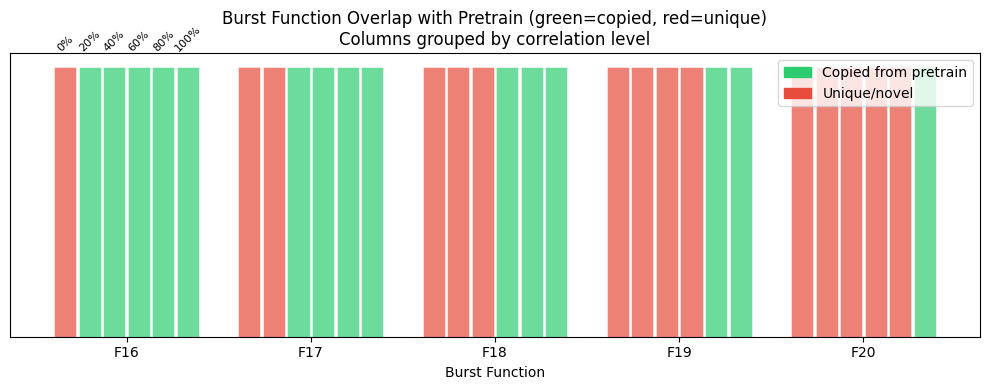

In [ ]:
# ── Inspect data: decode sample docs + bar chart of bijection overlap ──

def _decode(seq, token_idx):
    _tok = {v: k for k, v in token_idx.items()}
    parts = []
    for t in seq:
        s = _tok.get(int(t), f"?{t}")
        parts.append("·" if s == " " else ("<P>" if s == "<PAD>" else s))
    return " ".join(parts)

# Print sample documents at each correlation level
for corr in CORRELATIONS:
    d = make_data_correlated(correlation=corr)
    n_corr_fns = d["task_info"]["n_correlated"]
    print(f"\n{'='*70}")
    print(f"Correlation = {corr:.0%}  ({n_corr_fns}/{N_BURST_FNS} burst fns copied from pretrain)")
    print(f"{'='*70}")

    burst_tok_pos = DEPTH - BURST_POS + 1
    pt_fns = list(range((burst_tok_pos - 1) * N_A + 1, burst_tok_pos * N_A + 1))
    for b in d["b_stars"]:
        match = None
        for p in pt_fns:
            if np.array_equal(d["bijections"][b], d["bijections"][p]):
                match = p
                break
        status = f"= F{match} (pretrain)" if match else "unique"
        print(f"  F{b}: {d['bijections'][b].tolist()}  {status}")

    burst_keys = [k for k in d["target_pool"] if k[0] == "burst"][:2]
    for key in burst_keys:
        doc = d["target_pool"][key][0]
        print(f"  Sample doc {key}: {_decode(doc, d['token_idx'])}")

# ── Bar chart: overlap structure at each correlation level ──
fig, ax = plt.subplots(figsize=(10, 4))
bar_width = 0.8 / len(CORRELATIONS)

for i, corr in enumerate(CORRELATIONS):
    d = make_data_correlated(correlation=corr)
    burst_tok_pos = DEPTH - BURST_POS + 1
    pt_fns = list(range((burst_tok_pos - 1) * N_A + 1, burst_tok_pos * N_A + 1))

    matches = []
    for b in d["b_stars"]:
        is_match = any(np.array_equal(d["bijections"][b], d["bijections"][p]) for p in pt_fns)
        matches.append(1 if is_match else 0)

    x = np.arange(len(d["b_stars"]))
    offset = (i - len(CORRELATIONS) / 2 + 0.5) * bar_width
    colors = ["#2ecc71" if m else "#e74c3c" for m in matches]
    ax.bar(x + offset, [1]*len(matches), bar_width * 0.9, color=colors, alpha=0.7,
           edgecolor="white", linewidth=0.5)
    ax.text(x[0] + offset, 1.05, f"{corr:.0%}", ha="center", va="bottom", fontsize=8, rotation=45)

ax.set_xticks(range(len(d["b_stars"])))
ax.set_xticklabels([f"F{b}" for b in d["b_stars"]])
ax.set_xlabel("Burst Function")
ax.set_ylabel("")
ax.set_yticks([])
ax.set_title("Burst Function Overlap with Pretrain (green=copied, red=unique)\n"
             "Columns grouped by correlation level")

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#2ecc71", label="Copied from pretrain"),
                   Patch(color="#e74c3c", label="Unique/novel")],
          loc="upper right")
fig.tight_layout()
plt.show()

## Pretrain (once)

Background data is the same regardless of correlation (burst functions aren't in the pretrain set), so we pretrain once and reuse the checkpoint.

Seed 43: Vocab=44, Context=37


Pretrain: 0it [00:00, ?it/s]


Converged at step 800 (eval loss plateaued for 5 checks)
Pretrain done: peak acc_other=1.0000, final loss_other=0.6103
  Checkpoint: data/correlation_burst/pretrain_s43/pretrain_ckpt.pt
Seed 45: Vocab=44, Context=37


Pretrain: 0it [00:00, ?it/s]


Converged at step 875 (eval loss plateaued for 5 checks)
Pretrain done: peak acc_other=1.0000, final loss_other=0.5999
  Checkpoint: data/correlation_burst/pretrain_s45/pretrain_ckpt.pt
Seed 46: Vocab=44, Context=37


Pretrain: 0it [00:00, ?it/s]


Converged at step 525 (eval loss plateaued for 5 checks)
Pretrain done: peak acc_other=1.0000, final loss_other=0.6113
  Checkpoint: data/correlation_burst/pretrain_s46/pretrain_ckpt.pt


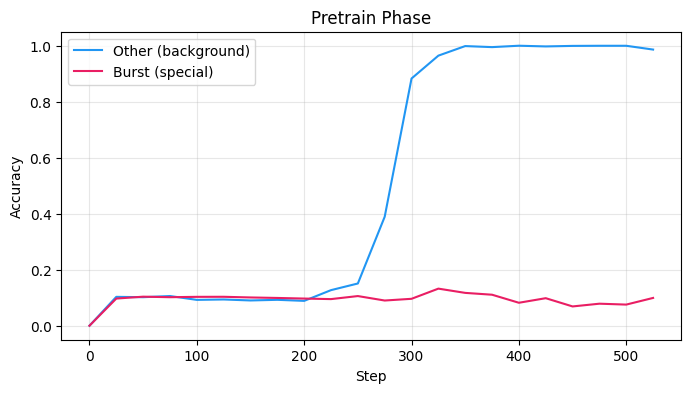

In [ ]:
# Pretrain once per seed (bg_pool is the same for all correlation levels)
all_pt = {}       # seed -> pt result
all_data_base = {} # seed -> base data

for seed in SEEDS:
    data_base = make_data_correlated(correlation=0.0, seed=seed)
    print(f"Seed {seed}: Vocab={data_base['vocab_size']}, Context={data_base['context_size']}")

    pt = pretrain(data_base, f"{OUT}/pretrain_s{seed}", seed=seed, lr=1e-3, batch_size=BATCH_SIZE)
    all_pt[seed] = pt
    all_data_base[seed] = data_base
    print(f"  Checkpoint: {pt['ckpt_path']}")

# Plot last seed as example
report.plot_pretrain(all_pt[SEEDS[-1]])
plt.show()


In [ ]:
# Fisher eigenvectors per seed
all_fisher = {}  # seed -> fisher_eigvecs

for seed in SEEDS:
    data_base = all_data_base[seed]
    pt = all_pt[seed]
    _net_pt = load_model(pt["ckpt_path"], data_base["vocab_size"], data_base["context_size"])
    fisher_eigvecs = compute_fisher_eigenvectors(
        _net_pt, data_base, k=5, n_power_iters=10, n_batches=16, batch_size=64, seed=seed,
    )
    all_fisher[seed] = fisher_eigvecs
    del _net_pt
    print(f"  Seed {seed}: Fisher done")


  Seed 43: Fisher done
  Seed 45: Fisher done
  Seed 46: Fisher done


## Finetune Sweep: Correlation x Concentration

For each correlation level, generate the corresponding data and sweep over burst fractions. All runs share the same pretrained checkpoint.

In [ ]:
import torch.multiprocessing as mp
from simple.finetune import _finetune_worker

all_ft_results = {}  # (seed, correlation, frac) -> ft_result
all_data = {}        # (seed, correlation) -> data dict

for seed in SEEDS:
    print(f"\n{'#'*60}")
    print(f"Seed = {seed}")
    print(f"{'#'*60}")
    pt = all_pt[seed]
    fisher_eigvecs = all_fisher[seed]

    for corr in CORRELATIONS:
        print(f"\n  Correlation = {corr:.2f}")

        data_corr = make_data_correlated(correlation=corr, seed=seed)
        all_data[(seed, corr)] = data_corr

        jobs = [
            dict(
                data=data_corr,
                pretrain_ckpt=pt["ckpt_path"],
                out_dir=f"{OUT}/finetune_s{seed}_corr{int(corr*100)}",
                burst_frac=frac,
                steps=1500,
                seed=seed,
                quiet=False,
                lr=1e-4,
                fisher_eigvecs=fisher_eigvecs,
                eval_every=50,
                grad_clip=1,
                batch_size=BATCH_SIZE,
                tag=f"s{seed}_corr{int(corr*100)}_burst_{int(frac*100)}",
            )
            for frac in FRACS
        ]

        ctx = mp.get_context("spawn")
        with ctx.Pool(len(FRACS)) as pool:
            ft_results = pool.map(_finetune_worker, jobs)

        for ft, frac in zip(ft_results, FRACS):
            all_ft_results[(seed, corr, frac)] = ft
            print(f"    frac={frac:.0%}: peak_burst={ft['peak_burst']:.3f}")

print(f"\nTotal runs: {len(all_ft_results)}")



############################################################
Seed = 43
############################################################

  Correlation = 0.00


Finetune s43_corr0_burst_50: 100%|██████████| 1500/1500 [03:46<00:00,  6.62it/s, acc_b=1.000, acc_o=1.000, drift=3.690, loss=0.6239]


    frac=100%: peak_burst=1.000
    frac=90%: peak_burst=1.000
    frac=80%: peak_burst=1.000
    frac=70%: peak_burst=1.000
    frac=60%: peak_burst=1.000
    frac=50%: peak_burst=1.000

  Correlation = 0.20


Finetune s43_corr20_burst_60: 100%|██████████| 1500/1500 [04:02<00:00,  6.18it/s, acc_b=1.000, acc_o=1.000, drift=3.556, loss=0.6240]


    frac=100%: peak_burst=1.000
    frac=90%: peak_burst=1.000
    frac=80%: peak_burst=1.000
    frac=70%: peak_burst=1.000
    frac=60%: peak_burst=1.000
    frac=50%: peak_burst=1.000

  Correlation = 0.40


...

    frac=100%: peak_burst=1.000
    frac=90%: peak_burst=1.000
    frac=80%: peak_burst=1.000
    frac=70%: peak_burst=1.000
    frac=60%: peak_burst=1.000
    frac=50%: peak_burst=1.000

  Correlation = 0.80


Finetune s46_corr80_burst_50: 100%|██████████| 1500/1500 [03:52<00:00,  6.44it/s, acc_b=1.000, acc_o=1.000, drift=3.049, loss=0.6240]


    frac=100%: peak_burst=1.000
    frac=90%: peak_burst=1.000
    frac=80%: peak_burst=1.000
    frac=70%: peak_burst=1.000
    frac=60%: peak_burst=1.000
    frac=50%: peak_burst=1.000

  Correlation = 1.00


Finetune s46_corr100_burst_50: 100%|██████████| 1500/1500 [03:49<00:00,  6.53it/s, acc_b=1.000, acc_o=1.000, drift=2.867, loss=0.6242]


    frac=100%: peak_burst=1.000
    frac=90%: peak_burst=1.000
    frac=80%: peak_burst=1.000
    frac=70%: peak_burst=1.000
    frac=60%: peak_burst=1.000
    frac=50%: peak_burst=1.000

Total runs: 108


## Forget Phase

For each finetuned model, measure reversion when trained on background data only.

In [ ]:
from simple.forget import _forget_worker

all_fg_results = {}  # (seed, correlation, frac) -> fg_result

for seed in SEEDS:
    print(f"\n--- Seed {seed} ---")
    pt = all_pt[seed]

    for corr in CORRELATIONS:
        print(f"  Forget: correlation={corr:.2f}")
        data_corr = all_data[(seed, corr)]

        jobs = [
            dict(
                data=data_corr,
                finetune_ckpt=all_ft_results[(seed, corr, frac)]["ckpt_path"],
                out_dir=f"{OUT}/forget_s{seed}_corr{int(corr*100)}",
                pretrain_ckpt=pt["ckpt_path"],
                steps=600,
                seed=seed,
                quiet=True,
                lr=1e-4,
                grad_clip=1,
                eval_every=50,
                batch_size=BATCH_SIZE,
            )
            for frac in FRACS
        ]

        ctx = mp.get_context("spawn")
        with ctx.Pool(len(FRACS)) as pool:
            fg_results = pool.map(_forget_worker, jobs)

        for fg, frac in zip(fg_results, FRACS):
            all_fg_results[(seed, corr, frac)] = fg
            print(f"    frac={frac:.0%}: peak={fg['peak_burst']:.3f} -> "
                  f"end={fg['end_burst_acc']:.3f} (drop {fg['dropoff_pct']:.1f}%)")



--- Seed 43 ---
  Forget: correlation=0.00
    frac=100%: peak=1.000 -> end=0.145 (drop 85.5%)
    frac=90%: peak=1.000 -> end=0.368 (drop 63.2%)
    frac=80%: peak=1.000 -> end=0.441 (drop 55.9%)
    frac=70%: peak=1.000 -> end=0.531 (drop 46.9%)
    frac=60%: peak=1.000 -> end=0.382 (drop 61.8%)
    frac=50%: peak=1.000 -> end=0.419 (drop 58.1%)
  Forget: correlation=0.20
    frac=100%: peak=1.000 -> end=0.050 (drop 95.0%)
    frac=90%: peak=1.000 -> end=0.337 (drop 66.3%)
    frac=80%: peak=1.000 -> end=0.172 (drop 82.8%)
    frac=70%: peak=1.000 -> end=0.178 (drop 82.2%)
    frac=60%: peak=1.000 -> end=0.212 (drop 78.8%)
    frac=50%: peak=1.000 -> end=0.542 (drop 45.8%)
  Forget: correlation=0.40
    frac=100%: peak=1.000 -> end=0.196 (drop 80.4%)
    frac=90%: peak=1.000 -> end=0.270 (drop 73.0%)
    frac=80%: peak=1.000 -> end=0.203 (drop 79.7%)
    frac=70%: peak=1.000 -> end=0.304 (drop 69.6%)
    frac=60%: peak=1.000 -> end=0.246 (drop 75.4%)
    frac=50%: peak=1.000 -> end=

## Results

### Summary Table

In [ ]:
# Summary table: mean +/- stderr across seeds
def _mean_stderr(vals):
    a = np.array(vals)
    return a.mean(), a.std(ddof=1) / np.sqrt(len(a)) if len(a) > 1 else 0.0

print(f"{'Corr':>6} {'Frac':>6} {'Peak Burst':>16} {'End Burst':>16} {'Drop%':>14} {'Rev AUC':>16}")
print("-" * 80)
for corr in CORRELATIONS:
    for frac in FRACS:
        peaks = [all_ft_results[(s, corr, frac)]['peak_burst'] for s in SEEDS]
        ends = [all_fg_results[(s, corr, frac)]['end_burst_acc'] for s in SEEDS]
        drops = [all_fg_results[(s, corr, frac)]['dropoff_pct'] for s in SEEDS]
        aucs = [all_fg_results[(s, corr, frac)]['reversion_auc'] for s in SEEDS]
        pm, ps = _mean_stderr(peaks)
        em, es = _mean_stderr(ends)
        dm, ds = _mean_stderr(drops)
        am, as_ = _mean_stderr(aucs)
        print(f"{corr:6.0%} {frac:6.0%} {pm:7.3f}\u00b1{ps:.3f} "
              f"{em:7.3f}\u00b1{es:.3f} {dm:6.1f}\u00b1{ds:.1f} {am:7.1f}\u00b1{as_:.1f}")
    print()


  Corr   Frac       Peak Burst        End Burst          Drop%          Rev AUC
--------------------------------------------------------------------------------
    0%   100%   1.000±0.000   0.137±0.000   86.3±0.0   108.5±0.0
    0%    90%   1.000±0.000   0.502±0.000   49.8±0.0   381.7±0.0
    0%    80%   1.000±0.000   0.624±0.000   37.6±0.0   401.6±0.0
    0%    70%   1.000±0.000   0.660±0.000   34.0±0.0   442.8±0.0
    0%    60%   1.000±0.000   0.700±0.000   30.0±0.0   473.1±0.0
    0%    50%   1.000±0.000   0.677±0.000   32.3±0.0   490.2±0.0

   20%   100%   1.000±0.000   0.259±0.000   74.1±0.0   168.4±0.0
   20%    90%   1.000±0.000   0.493±0.000   50.7±0.0   357.3±0.0
   20%    80%   1.000±0.000   0.353±0.000   64.7±0.0   243.0±0.0
   20%    70%   1.000±0.000   0.452±0.000   54.8±0.0   312.8±0.0
   20%    60%   1.000±0.000   0.381±0.000   61.9±0.0   279.5±0.0
   20%    50%   1.000±0.000   0.449±0.000   55.1±0.0   315.6±0.0

   40%   100%   1.000±0.000   0.307±0.000   69.3±0.0   20

### Peak Burst Accuracy: Correlation x Concentration

/venv/main/lib/python3.12/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/venv/main/lib/python3.12/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


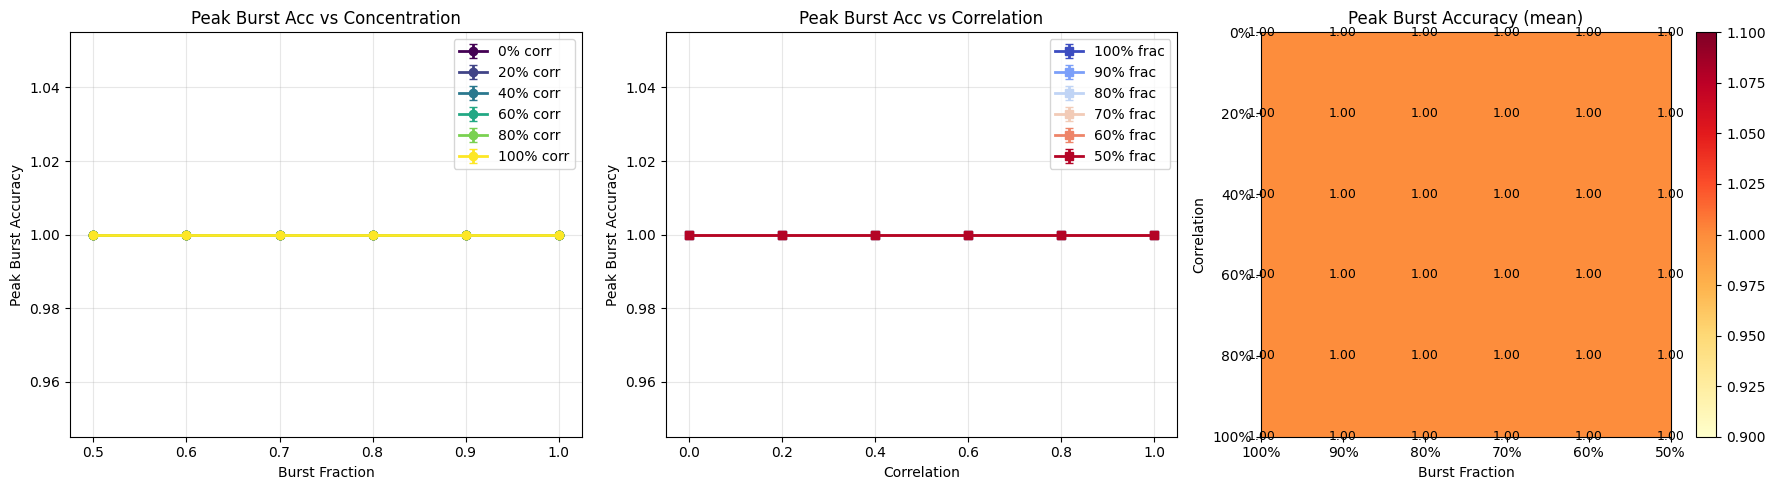

In [ ]:
# Peak burst accuracy: mean +/- stderr across seeds
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cmap = plt.cm.viridis

# Helper: gather metric across seeds
def _gather_ft(corr, frac, key):
    return [all_ft_results[(s, corr, frac)][key] for s in SEEDS]

def _gather_fg(corr, frac, key):
    return [all_fg_results[(s, corr, frac)][key] for s in SEEDS]

# (a) Peak burst acc vs concentration, grouped by correlation
ax = axes[0]
for i, corr in enumerate(CORRELATIONS):
    color = cmap(i / max(len(CORRELATIONS) - 1, 1))
    means = [np.mean(_gather_ft(corr, f, 'peak_burst')) for f in FRACS]
    stderrs = [np.std(_gather_ft(corr, f, 'peak_burst'), ddof=1) / np.sqrt(len(SEEDS))
              for f in FRACS]
    ax.errorbar(FRACS, means, yerr=stderrs, fmt="o-", color=color,
               label=f"{corr:.0%} corr", linewidth=2, capsize=3)
ax.set_xlabel("Burst Fraction")
ax.set_ylabel("Peak Burst Accuracy")
ax.set_title("Peak Burst Acc vs Concentration")
ax.legend()
ax.grid(True, alpha=0.3)

# (b) Peak burst acc vs correlation, grouped by concentration
ax = axes[1]
frac_cmap = plt.cm.coolwarm
for i, frac in enumerate(FRACS):
    color = frac_cmap(i / max(len(FRACS) - 1, 1))
    means = [np.mean(_gather_ft(corr, frac, 'peak_burst')) for corr in CORRELATIONS]
    stderrs = [np.std(_gather_ft(corr, frac, 'peak_burst'), ddof=1) / np.sqrt(len(SEEDS))
              for corr in CORRELATIONS]
    ax.errorbar(CORRELATIONS, means, yerr=stderrs, fmt="s-", color=color,
               label=f"{frac:.0%} frac", linewidth=2, capsize=3)
ax.set_xlabel("Correlation")
ax.set_ylabel("Peak Burst Accuracy")
ax.set_title("Peak Burst Acc vs Correlation")
ax.legend()
ax.grid(True, alpha=0.3)

# (c) Heatmap (mean across seeds)
peak_grid = np.array([[np.mean(_gather_ft(c, f, 'peak_burst'))
                        for f in FRACS] for c in CORRELATIONS])
ax = axes[2]
im = ax.imshow(peak_grid, aspect="auto", cmap="YlOrRd",
               extent=[0, len(FRACS)-1, len(CORRELATIONS)-1, 0])
ax.set_xticks(range(len(FRACS)))
ax.set_xticklabels([f"{f:.0%}" for f in FRACS])
ax.set_yticks(range(len(CORRELATIONS)))
ax.set_yticklabels([f"{c:.0%}" for c in CORRELATIONS])
ax.set_xlabel("Burst Fraction")
ax.set_ylabel("Correlation")
ax.set_title("Peak Burst Accuracy (mean)")
for ci in range(len(CORRELATIONS)):
    for fi in range(len(FRACS)):
        ax.text(fi, ci, f"{peak_grid[ci, fi]:.2f}", ha="center", va="center", fontsize=9)
plt.colorbar(im, ax=ax)

fig.tight_layout()
plt.show()


### Forgetting: Retention and Reversion AUC

In [ ]:
# Forgetting metrics: mean +/- stderr across seeds
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cmap = plt.cm.viridis

def _retention(seed, corr, frac):
    fg = all_fg_results[(seed, corr, frac)]
    return fg['end_burst_acc'] / fg['peak_burst'] if fg['peak_burst'] > 1e-6 else 0.0

# (a) Retention vs concentration, grouped by correlation
ax = axes[0]
for i, corr in enumerate(CORRELATIONS):
    color = cmap(i / max(len(CORRELATIONS) - 1, 1))
    means = [np.mean([_retention(s, corr, f) for s in SEEDS]) for f in FRACS]
    stderrs = [np.std([_retention(s, corr, f) for s in SEEDS], ddof=1) / np.sqrt(len(SEEDS))
              for f in FRACS]
    ax.errorbar(FRACS, means, yerr=stderrs, fmt="o-", color=color,
               label=f"{corr:.0%} corr", linewidth=2, capsize=3)
ax.set_xlabel("Burst Fraction")
ax.set_ylabel("Retention (end/peak)")
ax.set_title("Burst Retention vs Concentration")
ax.legend()
ax.grid(True, alpha=0.3)

# (b) Retention vs correlation, grouped by concentration
ax = axes[1]
frac_cmap = plt.cm.coolwarm
for i, frac in enumerate(FRACS):
    color = frac_cmap(i / max(len(FRACS) - 1, 1))
    means = [np.mean([_retention(s, corr, frac) for s in SEEDS]) for corr in CORRELATIONS]
    stderrs = [np.std([_retention(s, corr, frac) for s in SEEDS], ddof=1) / np.sqrt(len(SEEDS))
              for corr in CORRELATIONS]
    ax.errorbar(CORRELATIONS, means, yerr=stderrs, fmt="s-", color=color,
               label=f"{frac:.0%} frac", linewidth=2, capsize=3)
ax.set_xlabel("Correlation")
ax.set_ylabel("Retention (end/peak)")
ax.set_title("Burst Retention vs Correlation")
ax.legend()
ax.grid(True, alpha=0.3)

# (c) Retention heatmap (mean)
ret_grid = np.array([
    [np.mean([_retention(s, c, f) for s in SEEDS])
     for f in FRACS]
    for c in CORRELATIONS
])
ax = axes[2]
im = ax.imshow(ret_grid, aspect="auto", cmap="YlGnBu",
               extent=[0, len(FRACS)-1, len(CORRELATIONS)-1, 0])
ax.set_xticks(range(len(FRACS)))
ax.set_xticklabels([f"{f:.0%}" for f in FRACS])
ax.set_yticks(range(len(CORRELATIONS)))
ax.set_yticklabels([f"{c:.0%}" for c in CORRELATIONS])
ax.set_xlabel("Burst Fraction")
ax.set_ylabel("Correlation")
ax.set_title("Retention (mean)")
for ci in range(len(CORRELATIONS)):
    for fi in range(len(FRACS)):
        ax.text(fi, ci, f"{ret_grid[ci, fi]:.2f}", ha="center", va="center", fontsize=9)
plt.colorbar(im, ax=ax)

fig.tight_layout()
plt.show()


In [ ]:
ret_grid

array([[0.137     , 0.50233333, 0.62373333, 0.6602    , 0.6996    ,
        0.67653333],
       [0.25926667, 0.49253333, 0.3526    , 0.45173333, 0.38086667,
        0.44886667],
       [0.30713333, 0.59166667, 0.65293333, 0.7272    , 0.71      ,
        0.61906667],
       [0.36126667, 0.56906667, 0.5144    , 0.644     , 0.56813333,
        0.81533333],
       [0.33073333, 0.6084    , 0.5984    , 0.69486667, 0.59106667,
        0.83773333],
       [0.3424    , 0.535     , 0.72726667, 0.85646667, 0.68866667,
        0.872     ]])

### Learning Trajectories by Correlation Level

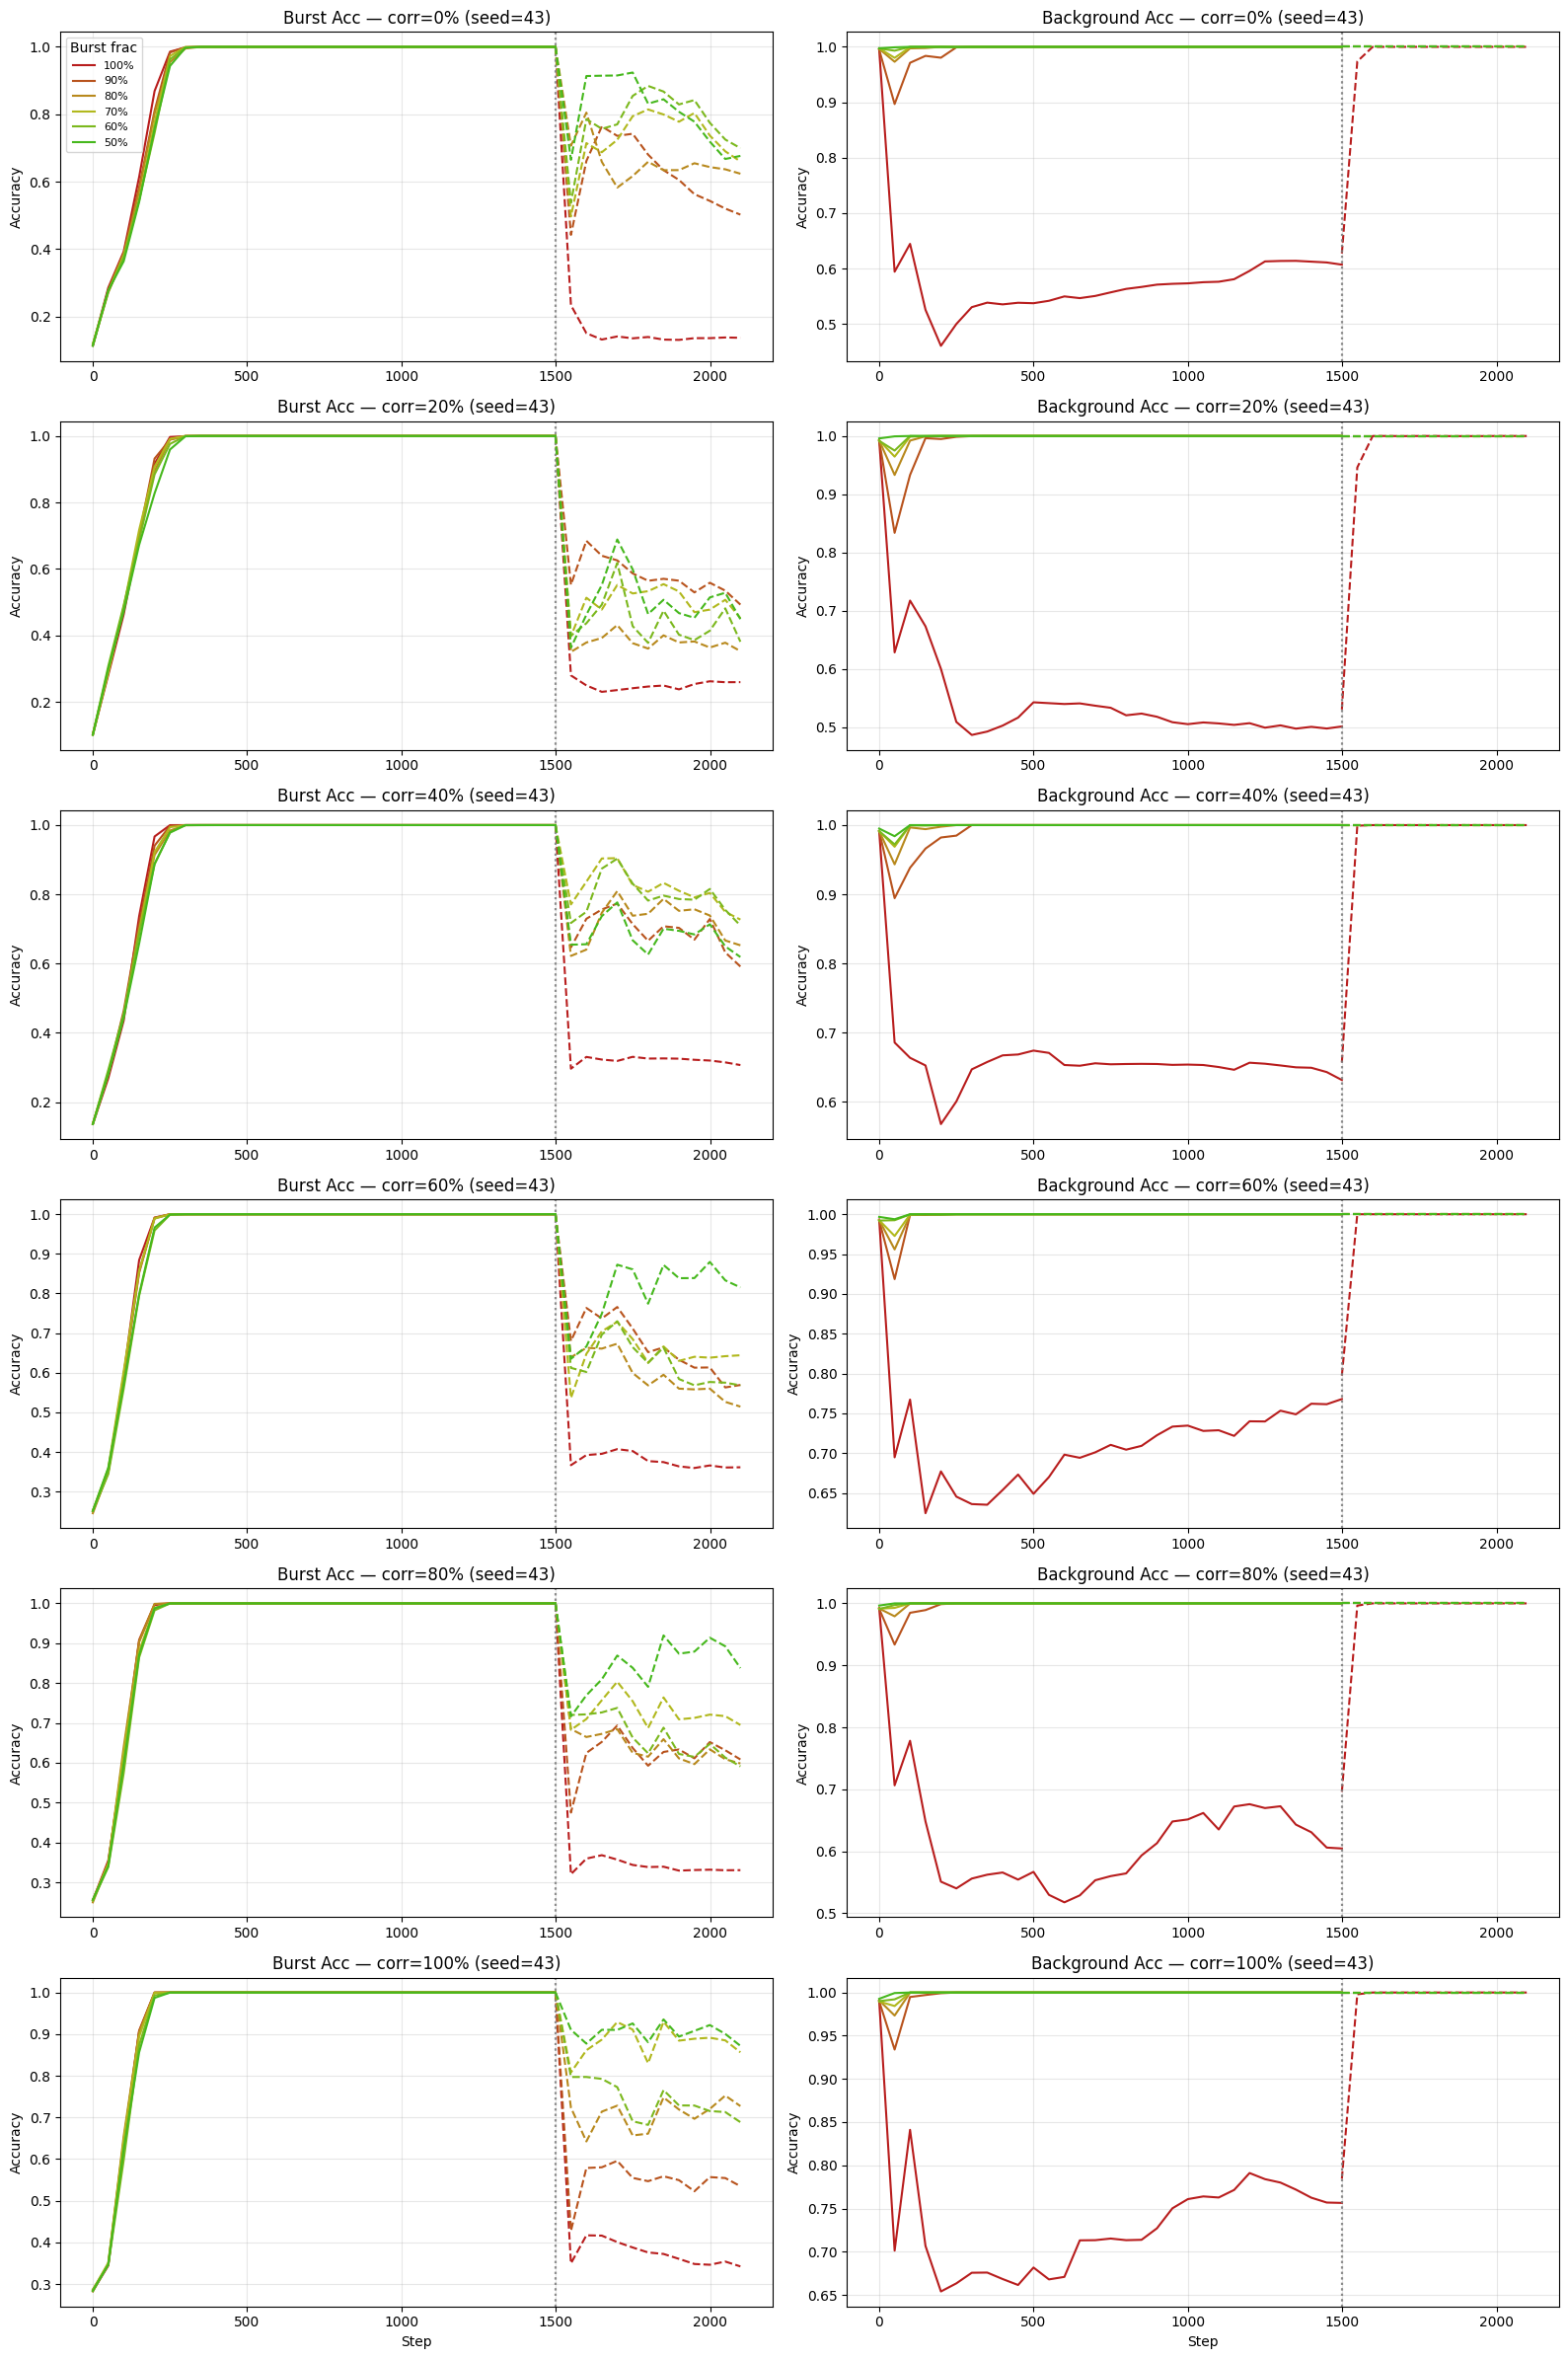

In [ ]:
# Full trajectories: finetune + forget (showing seed=SEEDS[0], representative)
# For multi-seed error bars see summary plots above
n_corr = len(CORRELATIONS)
fig, axes = plt.subplots(n_corr, 2, figsize=(16, 4 * n_corr), squeeze=False)
seed0 = SEEDS[0]

for row, corr in enumerate(CORRELATIONS):
    # Burst accuracy
    ax = axes[row, 0]
    for frac in FRACS:
        ft = all_ft_results[(seed0, corr, frac)]
        fg = all_fg_results[(seed0, corr, frac)]
        color = report._frac_color(frac)

        ft_steps = ft["log"]["step"]
        fg_steps = [s + ft_steps[-1] for s in fg["log"]["step"]]
        ax.plot(ft_steps, ft["log"]["acc_burst"], "-", color=color,
                label=f"{frac:.0%}", linewidth=1.5)
        ax.plot(fg_steps, fg["log"]["acc_burst"], "--", color=color, linewidth=1.5)
        ax.axvline(ft_steps[-1], color="gray", linestyle=":", alpha=0.3)

    ax.set_title(f"Burst Acc — corr={corr:.0%} (seed={seed0})")
    ax.set_ylabel("Accuracy")
    if row == 0:
        ax.legend(title="Burst frac", fontsize=8)
    ax.grid(True, alpha=0.3)

    # Background accuracy
    ax = axes[row, 1]
    for frac in FRACS:
        ft = all_ft_results[(seed0, corr, frac)]
        fg = all_fg_results[(seed0, corr, frac)]
        color = report._frac_color(frac)

        ft_steps = ft["log"]["step"]
        fg_steps = [s + ft_steps[-1] for s in fg["log"]["step"]]
        ax.plot(ft_steps, ft["log"]["acc_other"], "-", color=color, linewidth=1.5)
        ax.plot(fg_steps, fg["log"]["acc_other"], "--", color=color, linewidth=1.5)
        ax.axvline(ft_steps[-1], color="gray", linestyle=":", alpha=0.3)

    ax.set_title(f"Background Acc — corr={corr:.0%} (seed={seed0})")
    ax.set_ylabel("Accuracy")
    ax.grid(True, alpha=0.3)

    if row == n_corr - 1:
        axes[row, 0].set_xlabel("Step")
        axes[row, 1].set_xlabel("Step")

fig.tight_layout()
plt.show()


### Weight Drift and Gradient Cosine

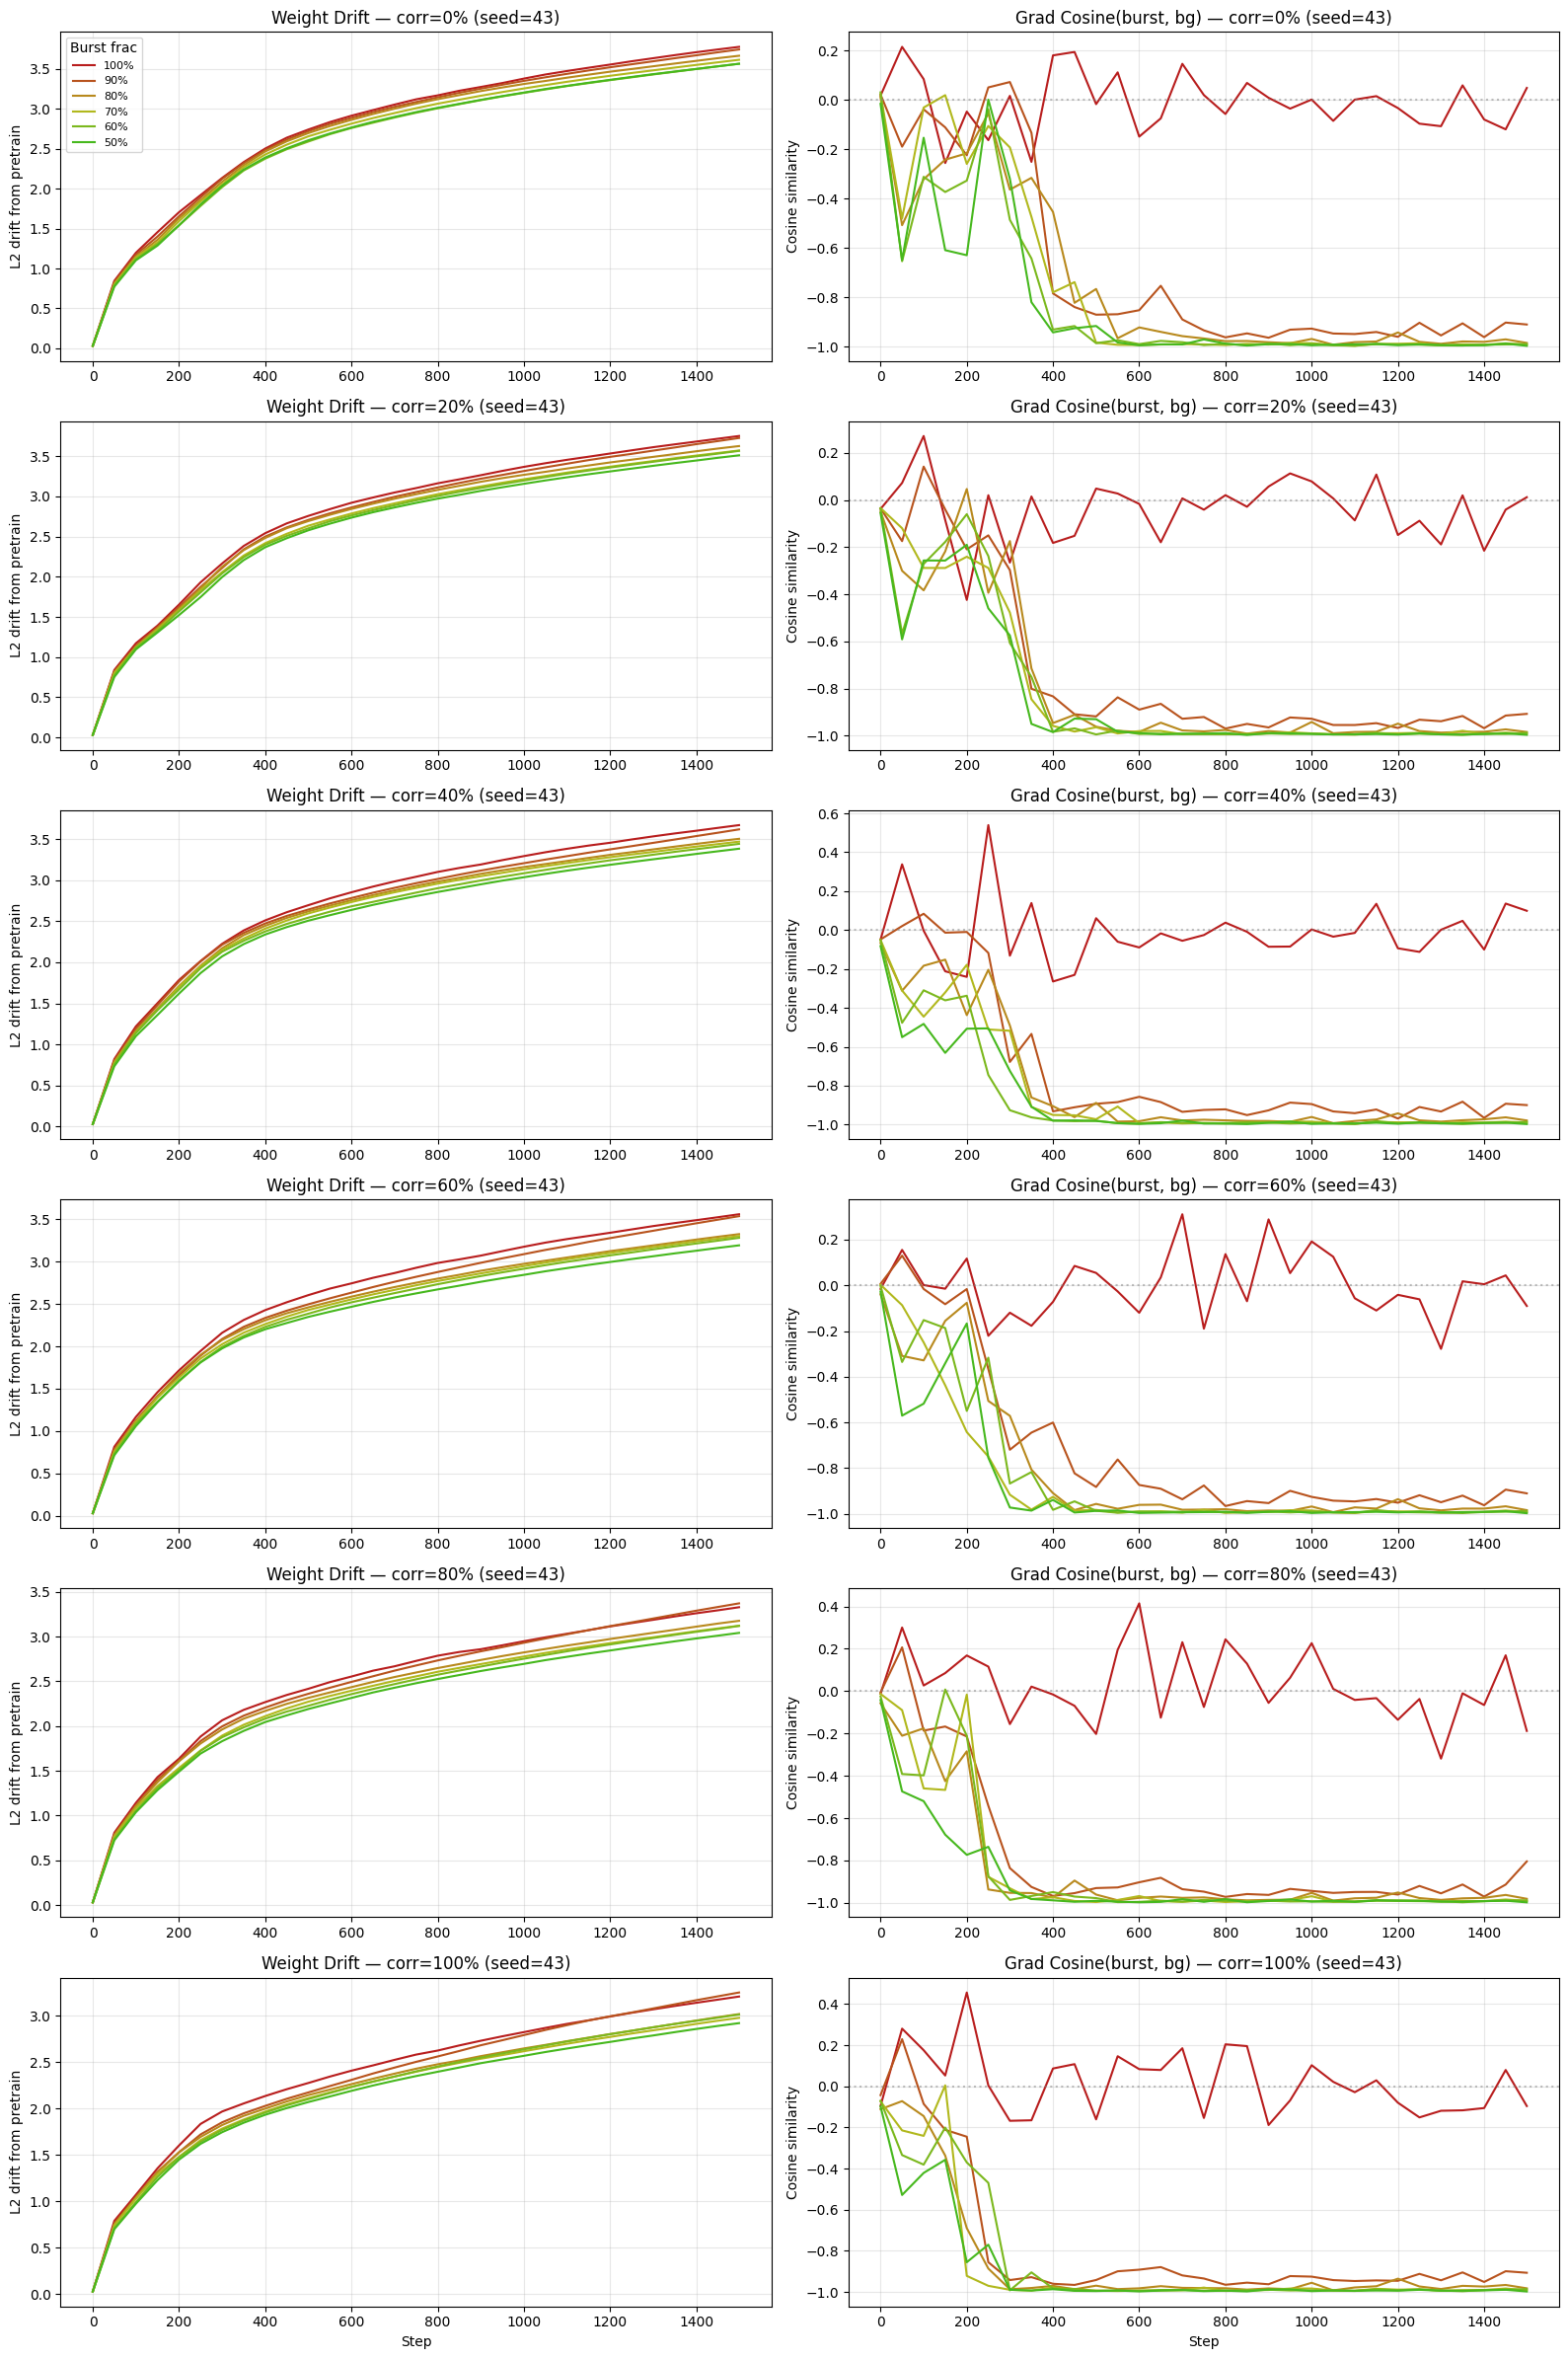

In [ ]:
# Weight drift and grad cosine(burst, bg) during finetuning (seed=SEEDS[0])
fig, axes = plt.subplots(n_corr, 2, figsize=(16, 4 * n_corr), squeeze=False)
seed0 = SEEDS[0]

for row, corr in enumerate(CORRELATIONS):
    # Weight drift
    ax = axes[row, 0]
    for frac in FRACS:
        ft = all_ft_results[(seed0, corr, frac)]
        color = report._frac_color(frac)
        ax.plot(ft["log"]["step"], ft["log"]["weight_drift"], "-",
                color=color, label=f"{frac:.0%}", linewidth=1.5)
    ax.set_title(f"Weight Drift — corr={corr:.0%} (seed={seed0})")
    ax.set_ylabel("L2 drift from pretrain")
    if row == 0:
        ax.legend(title="Burst frac", fontsize=8)
    ax.grid(True, alpha=0.3)

    # Gradient cosine (burst vs bg)
    ax = axes[row, 1]
    for frac in FRACS:
        ft = all_ft_results[(seed0, corr, frac)]
        color = report._frac_color(frac)
        ax.plot(ft["log"]["step"], ft["log"]["grad_cosine_burst_bg"], "-",
                color=color, linewidth=1.5)
    ax.set_title(f"Grad Cosine(burst, bg) — corr={corr:.0%} (seed={seed0})")
    ax.set_ylabel("Cosine similarity")
    ax.axhline(0, color="gray", linestyle=":", alpha=0.5)
    ax.grid(True, alpha=0.3)

    if row == n_corr - 1:
        axes[row, 0].set_xlabel("Step")
        axes[row, 1].set_xlabel("Step")

fig.tight_layout()
plt.show()


### Correlation Effect at Fixed Concentration

Compare learning curves across correlation levels, holding concentration fixed.

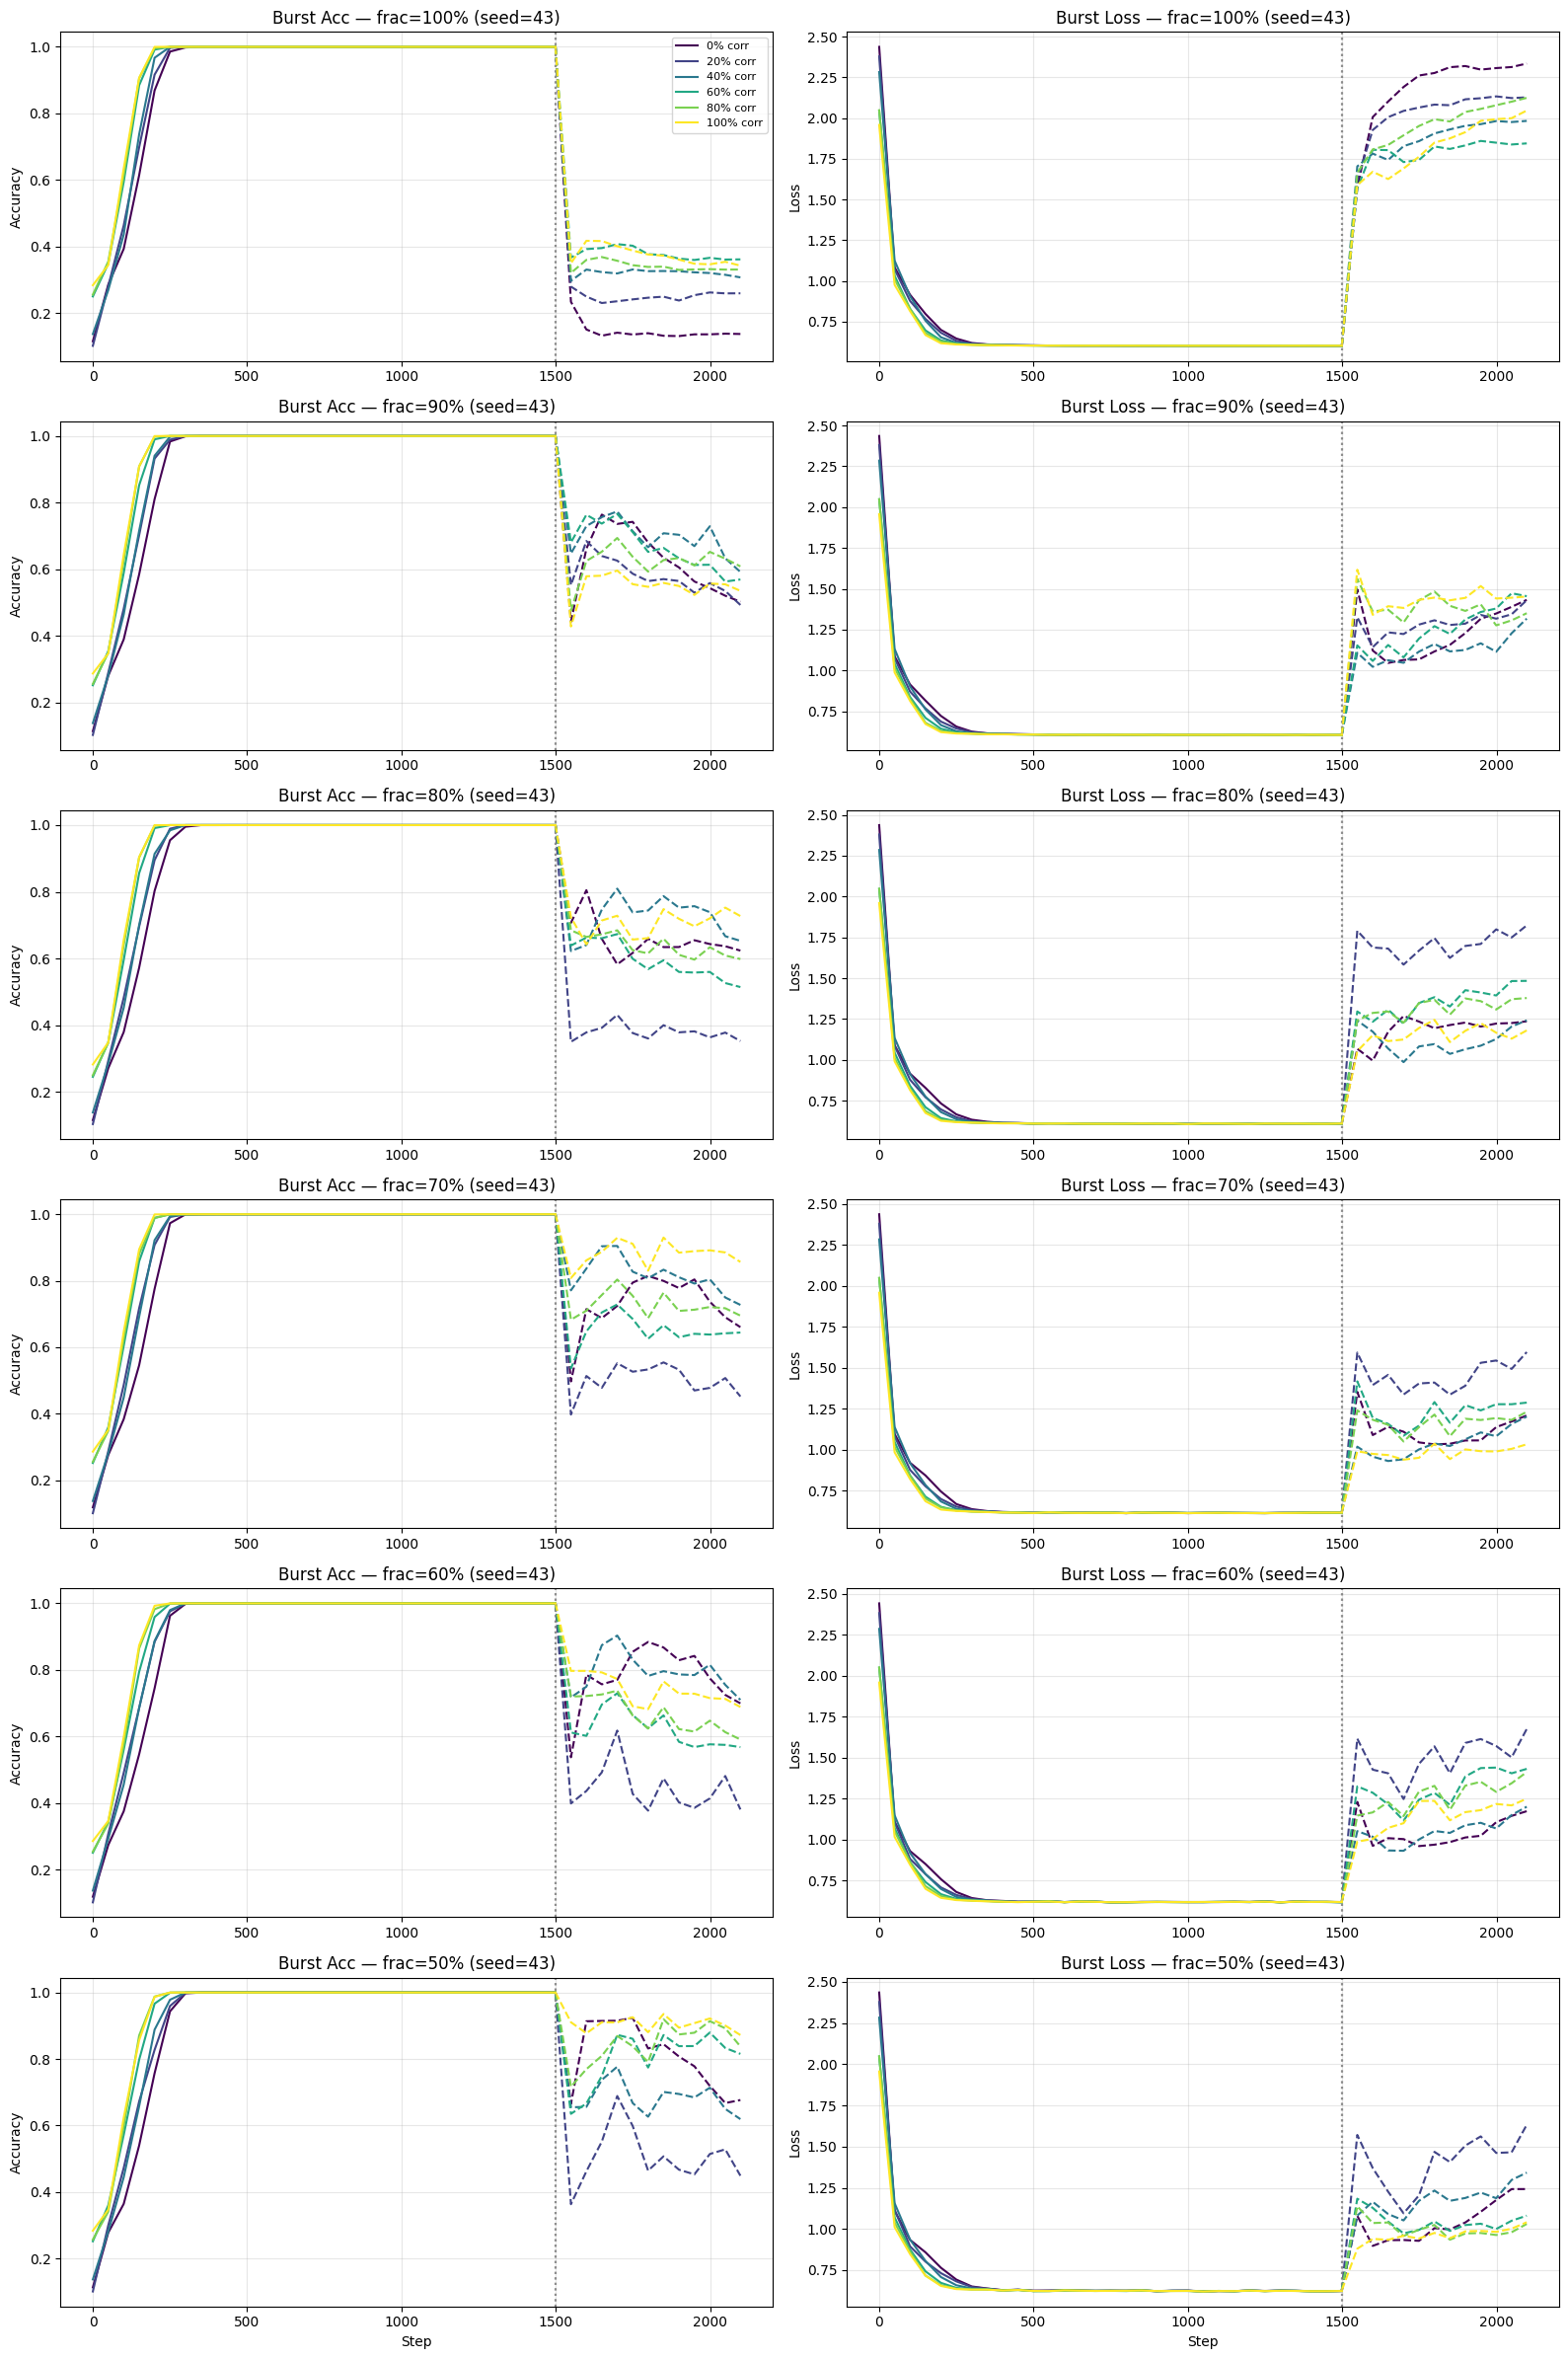

In [ ]:
# Learning curves at fixed concentration, varying correlation (seed=SEEDS[0])
n_frac = len(FRACS)
fig, axes = plt.subplots(n_frac, 2, figsize=(16, 4 * n_frac), squeeze=False)
cmap = plt.cm.viridis
seed0 = SEEDS[0]

for row, frac in enumerate(FRACS):
    # Burst accuracy
    ax = axes[row, 0]
    for i, corr in enumerate(CORRELATIONS):
        ft = all_ft_results[(seed0, corr, frac)]
        fg = all_fg_results[(seed0, corr, frac)]
        color = cmap(i / max(len(CORRELATIONS) - 1, 1))

        ft_steps = ft["log"]["step"]
        fg_steps = [s + ft_steps[-1] for s in fg["log"]["step"]]
        ax.plot(ft_steps, ft["log"]["acc_burst"], "-", color=color,
                label=f"{corr:.0%} corr", linewidth=1.5)
        ax.plot(fg_steps, fg["log"]["acc_burst"], "--", color=color, linewidth=1.5)
        ax.axvline(ft_steps[-1], color="gray", linestyle=":", alpha=0.3)
    ax.set_title(f"Burst Acc — frac={frac:.0%} (seed={seed0})")
    ax.set_ylabel("Accuracy")
    if row == 0:
        ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # Burst loss
    ax = axes[row, 1]
    for i, corr in enumerate(CORRELATIONS):
        ft = all_ft_results[(seed0, corr, frac)]
        fg = all_fg_results[(seed0, corr, frac)]
        color = cmap(i / max(len(CORRELATIONS) - 1, 1))

        ft_steps = ft["log"]["step"]
        fg_steps = [s + ft_steps[-1] for s in fg["log"]["step"]]
        ax.plot(ft_steps, ft["log"]["loss_burst"], "-", color=color, linewidth=1.5)
        ax.plot(fg_steps, fg["log"]["loss_burst"], "--", color=color, linewidth=1.5)
        ax.axvline(ft_steps[-1], color="gray", linestyle=":", alpha=0.3)
    ax.set_title(f"Burst Loss — frac={frac:.0%} (seed={seed0})")
    ax.set_ylabel("Loss")
    ax.grid(True, alpha=0.3)

    if row == n_frac - 1:
        axes[row, 0].set_xlabel("Step")
        axes[row, 1].set_xlabel("Step")

fig.tight_layout()
plt.show()
